# Employee Performance Analysis

## INX Future Inc.

### Project Objective

The objective of this project is to analyze employee performance data and identify the factors affecting employee performance.

The project will:

1. Analyze department-wise performance.
2. Identify the top factors affecting employee performance.
3. Build a machine learning model to predict employee performance.
4. Provide recommendations to improve employee performance.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

## Loading the Dataset

In this step, the employee performance dataset is loaded into Python using Pandas. The dataset will be used for further analysis and model development.

In [2]:
file_path=r"C:\Users\nimba\Desktop\INX_Employee_Performance_Project\data\raw\INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls"
df=pd.read_excel(file_path)
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [3]:
!pip install xlrd


## Dataset Overview

In this section, we examine the structure of the dataset including the number of rows and columns.

In [4]:
df.shape # 1200(rows) employees and 28(columns) employees information 

(1200, 28)

## Column Names

The following columns are available in the employee performance dataset.

In [5]:
df.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

## Dataset Information

This section provides information about column names, data types, and non-null values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [7]:
df.isnull().sum() # checking for missing values 


EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

## Target Variable Analysis

In this section, we analyze the PerformanceRating column, which is the target variable for prediction.

In [8]:
df["PerformanceRating"].value_counts()

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

In [9]:
df["PerformanceRating"].value_counts(normalize=True)*100

PerformanceRating
3    72.833333
2    16.166667
4    11.000000
Name: proportion, dtype: float64

The employee performance rating distribution indicates that the majority of employees (72.83%) belong to Performance Rating 3. Employees with Rating 2 account for 16.17% of the workforce, while employees with Rating 4 account for 11%.

This indicates that the dataset is moderately imbalanced with Performance Rating 3 being the dominant class.

## Performance Rating Distribution

The following visualization shows the distribution of employee performance ratings.

Text(0, 0.5, 'Number of Employees')

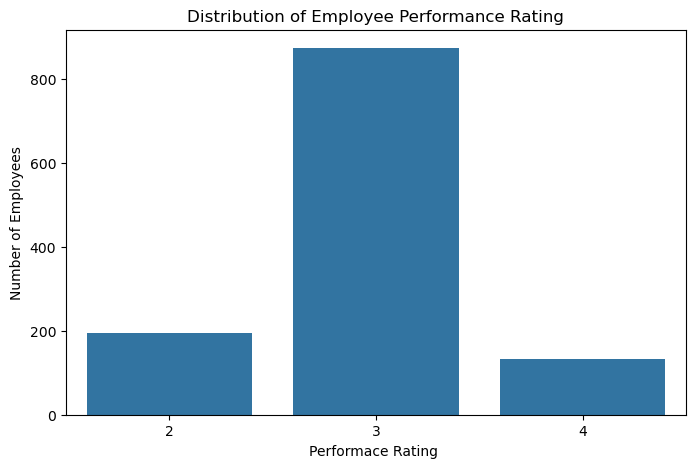

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x="PerformanceRating",data=df)
plt.title("Distribution of Employee Performance Rating")
plt.xlabel("Performace Rating ")
plt.ylabel("Number of Employees")

## Department-wise Performance Analysis

This analysis evaluates employee performance across different departments to identify departments with higher and lower performance ratings.

In [11]:
df.groupby("EmpDepartment")["PerformanceRating"].mean()

EmpDepartment
Data Science              3.050000
Development               3.085873
Finance                   2.775510
Human Resources           2.925926
Research & Development    2.921283
Sales                     2.860590
Name: PerformanceRating, dtype: float64

### Insight

The Development department has the highest average employee performance rating (3.09), indicating comparatively stronger employee performance.

The Finance department has the lowest average performance rating (2.78), suggesting that further investigation may be required to understand factors affecting employee performance within this department.

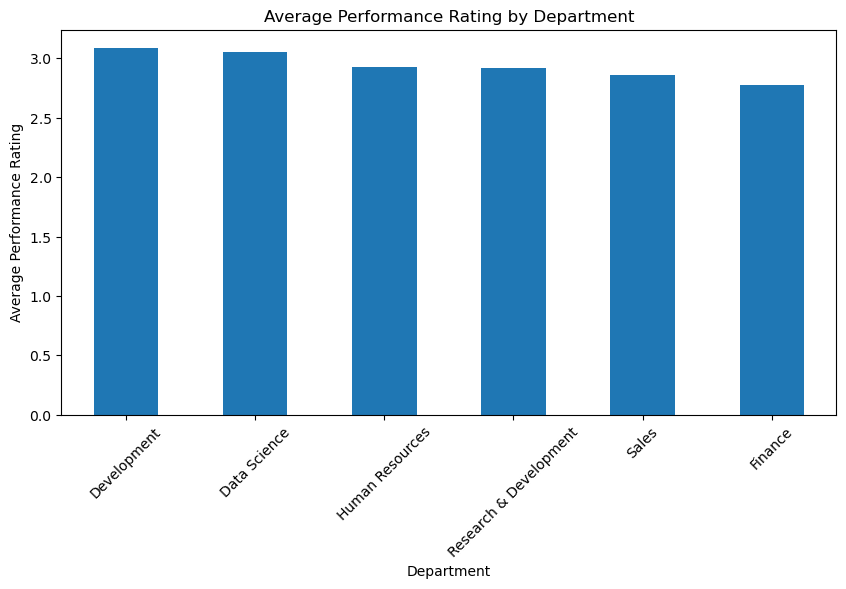

In [12]:
department_performance = df.groupby("EmpDepartment")["PerformanceRating"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

department_performance.plot(kind="bar")

plt.title("Average Performance Rating by Department")
plt.xlabel("Department")
plt.ylabel("Average Performance Rating")

plt.xticks(rotation=45)

plt.show()

### Department-wise Performance Insights

The Development department achieved the highest average employee performance rating (3.09), followed closely by the Data Science department (3.05).

The Finance department recorded the lowest average performance rating (2.78), indicating potential opportunities for performance improvement initiatives.

The difference between departments is relatively small, suggesting that employee performance is influenced not only by department but also by individual and workplace-related factors.

## Performance vs Overtime

This analysis examines whether overtime has any relationship with employee performance ratings.

In [13]:
pd.crosstab(df["OverTime"],df["PerformanceRating"])

PerformanceRating,2,3,4
OverTime,,,
No,155,595,97
Yes,39,279,35


In [14]:
pd.crosstab(df["OverTime"],df["PerformanceRating"],normalize="index")*100

PerformanceRating,2,3,4
OverTime,,,
No,18.299882,70.247934,11.452184
Yes,11.048159,79.036827,9.915014


### Insight

Employees working overtime show a lower percentage of Performance Rating 2 employees compared to employees who do not work overtime.

However, the percentage of employees with the highest Performance Rating (4) is similar in both groups.

This suggests that overtime may have a moderate influence on employee performance but is unlikely to be the strongest performance-driving factor.

## Performance vs Job Satisfaction

This analysis investigates the relationship between employee job satisfaction and performance ratings.

In [15]:
df.groupby("EmpJobSatisfaction")["PerformanceRating"].mean()

EmpJobSatisfaction
1    2.969697
2    2.953586
3    2.898305
4    2.978836
Name: PerformanceRating, dtype: float64

### Insight

The average performance ratings across all job satisfaction levels are very similar.

No clear increasing or decreasing trend is observed between job satisfaction and performance rating.

This suggests that job satisfaction alone may not be a major factor influencing employee performance within the organization.

## Performance vs Environment Satisfaction

This analysis investigates whether employee satisfaction with the work environment influences performance ratings.

In [16]:
df.groupby("EmpEnvironmentSatisfaction")["PerformanceRating"].mean()

EmpEnvironmentSatisfaction
1    2.665217
2    2.652893
3    3.138965
4    3.132964
Name: PerformanceRating, dtype: float64

## Performance vs Work-Life Balance

This analysis investigates the relationship between employee work-life balance and performance ratings.

Work-life balance reflects how effectively employees manage their professional and personal responsibilities. The objective is to determine whether better work-life balance is associated with higher employee performance.

In [17]:
df.groupby("EmpWorkLifeBalance")["PerformanceRating"].mean()

EmpWorkLifeBalance
1    2.750000
2    2.918367
3    2.950481
4    3.121739
Name: PerformanceRating, dtype: float64

## Performance vs Job Involvement

This analysis evaluates the impact of employee job involvement on performance ratings.

Job involvement measures the degree of employee participation, commitment, and engagement in their work. Higher involvement may contribute to improved employee performance.

In [18]:
df.groupby("EmpJobInvolvement")["PerformanceRating"].mean()

EmpJobInvolvement
1    2.957143
2    2.959184
3    2.943370
4    2.946429
Name: PerformanceRating, dtype: float64

## Performance vs Job Level

This analysis examines the relationship between employee job level and performance ratings.

Employees at different job levels may have varying responsibilities, experience, and expectations. This analysis helps determine whether performance differs across job levels.

In [19]:
df.groupby("EmpJobLevel")["PerformanceRating"].mean()

EmpJobLevel
1    2.993182
2    2.947846
3    2.890173
4    2.888889
5    2.875000
Name: PerformanceRating, dtype: float64

## Performance vs Training Times Last Year

This analysis investigates whether the number of training sessions attended by employees influences performance ratings.

Training programs are designed to improve employee skills and productivity. The objective is to identify whether employees receiving more training demonstrate higher performance.

In [20]:
df.groupby("TrainingTimesLastYear")["PerformanceRating"].mean()

TrainingTimesLastYear
0    2.863636
1    2.946429
2    2.948315
3    2.975787
4    2.918367
5    2.938776
6    2.869565
Name: PerformanceRating, dtype: float64

## Performance vs Relationship Satisfaction

This analysis evaluates the relationship between employee relationship satisfaction and performance ratings.

Relationship satisfaction reflects employee satisfaction with workplace relationships, including interactions with colleagues and supervisors. The objective is to determine whether positive workplace relationships contribute to improved employee performance.

In [21]:
df.groupby("EmpRelationshipSatisfaction")["PerformanceRating"].mean()

EmpRelationshipSatisfaction
1    2.949772
2    2.955466
3    2.970976
4    2.918310
Name: PerformanceRating, dtype: float64

## Top Factors Affecting Employee Performance

Based on exploratory data analysis, the following factors demonstrate the strongest relationship with employee performance:

1. Environment Satisfaction
2. Work-Life Balance
3. Training Times Last Year

Employees with higher environment satisfaction and better work-life balance generally achieve higher performance ratings. Training participation also appears to contribute positively to employee performance.

Factors such as job involvement, relationship satisfaction, and job satisfaction show comparatively weaker relationships with performance ratings.

## Environment Satisfaction vs Performance Rating

This visualization shows the relationship between employee environment satisfaction and average performance rating.

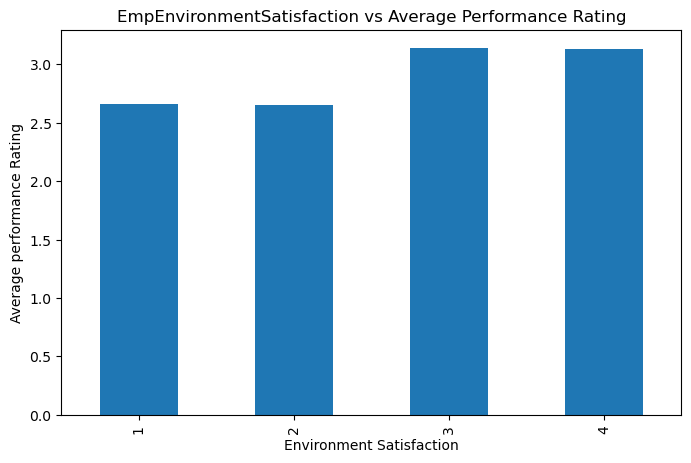

In [22]:
environment_perf=df.groupby("EmpEnvironmentSatisfaction")["PerformanceRating"].mean()
plt.figure(figsize=(8,5))
environment_perf.plot(kind="bar")
plt.title("EmpEnvironmentSatisfaction vs Average Performance Rating")
plt.xlabel("Environment Satisfaction")
plt.ylabel("Average performance Rating")
plt.show()

## Saving Processed Dataset

The dataset has been verified for missing values and basic quality checks. A processed copy of the dataset is saved for further exploratory analysis and model development.

In [23]:
df.to_csv(
    r"C:\Users\nimba\Desktop\INX_Employee_Performance_Project\data\processed\employee_performance_processed.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.
